In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Load data:

In [5]:
path = "DataSet"
print("Path to dataset files:", path)

Path to dataset files: DataSet


In [6]:
train_df = pd.read_csv(f'{path}/train.csv', encoding='latin1')
test_df = pd.read_csv(f'{path}/test.csv', encoding='latin1')
train_df.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


## Data preprocessing and EDA:

### EDA:

In [7]:
train_df.isnull().sum()

textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

In [8]:
test_df.isnull().sum()

textID              1281
text                1281
sentiment           1281
Time of Tweet       1281
Age of User         1281
Country             1281
Population -2020    1281
Land Area (Km²)     1281
Density (P/Km²)     1281
dtype: int64

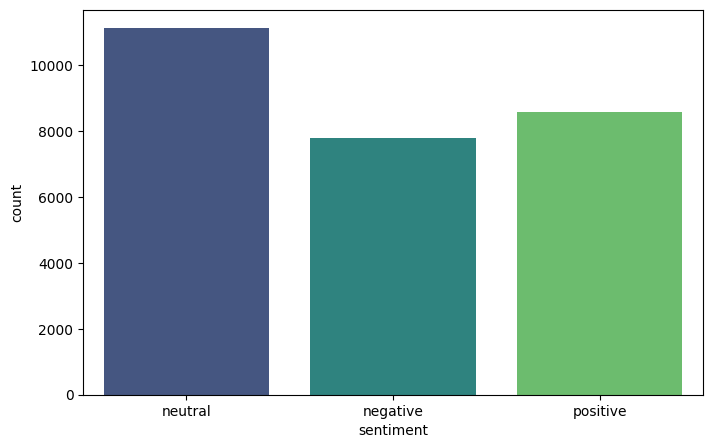

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='sentiment', hue='sentiment', palette='viridis')
plt.show()

In [10]:
# Drop the null values:

In [11]:
train_df = train_df.dropna()
test_df = test_df.dropna()

In [12]:
train_df.isnull().sum()

textID              0
text                0
selected_text       0
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

In [13]:
test_df.isnull().sum()

textID              0
text                0
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64

In [14]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            27480 non-null  str    
 1   text              27480 non-null  str    
 2   selected_text     27480 non-null  str    
 3   sentiment         27480 non-null  str    
 4   Time of Tweet     27480 non-null  str    
 5   Age of User       27480 non-null  str    
 6   Country           27480 non-null  str    
 7   Population -2020  27480 non-null  int64  
 8   Land Area (Km²)   27480 non-null  float64
 9   Density (P/Km²)   27480 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 6.0 MB


In [15]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3534 entries, 0 to 3533
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            3534 non-null   str    
 1   text              3534 non-null   str    
 2   sentiment         3534 non-null   str    
 3   Time of Tweet     3534 non-null   str    
 4   Age of User       3534 non-null   str    
 5   Country           3534 non-null   str    
 6   Population -2020  3534 non-null   float64
 7   Land Area (Km²)   3534 non-null   float64
 8   Density (P/Km²)   3534 non-null   float64
dtypes: float64(3), str(6)
memory usage: 612.6 KB


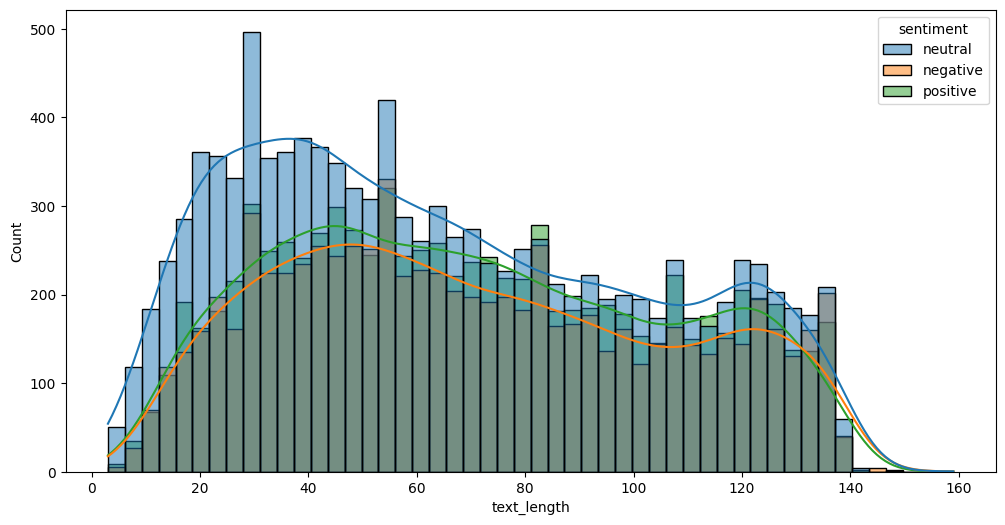

In [16]:
# Explore text length distribution
train_df['text_length'] = train_df['text'].apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(data=train_df, x='text_length', hue='sentiment', bins=50, kde=True)
plt.show()

### Text Cleaning and Preprocessing:

In [17]:
import regex as re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [18]:
def clean_text(text):
    
    if not text:
        return ""
        
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags (keeping the text after #)
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [19]:
def preprocess_text(text):
    
    if not text:
        return ""

    # Clean text
    text = clean_text(text)
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    # Join tokens back into text
    processed_text = ' '.join(tokens)
    
    return processed_text

In [20]:
train_cleaned = train_df.copy()
test_cleaned = test_df.copy()

train_cleaned['processed_text'] = train_df['text'].apply(preprocess_text)
test_cleaned['processed_text'] = test_df['text'].apply(preprocess_text)

In [21]:
train_cleaned.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),text_length,processed_text
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60,36,id responded going
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105,46,sooo sad miss san diego
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18,25,bos bullying
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164,31,interview leave alone
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26,75,son couldnt put release already bought


In [22]:
# Original vs processed text:
print(f"Original: {train_cleaned.iloc[0]['text']}")
print(f"Processed: {train_cleaned.iloc[0]['processed_text']}")

Original:  I`d have responded, if I were going
Processed: id responded going


## Prepare data for modeling:

In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
le = LabelEncoder()

# Fit and transform
train_cleaned['sentiment_encoded'] = le.fit_transform(train_cleaned['sentiment'])
test_cleaned['sentiment_encoded'] = le.fit_transform(test_cleaned['sentiment'])

In [25]:
train_cleaned['sentiment_encoded'].value_counts()

sentiment_encoded
1    11117
2     8582
0     7781
Name: count, dtype: int64

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = train_cleaned['processed_text']
y = train_cleaned['sentiment_encoded']

In [28]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
print("Training set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])

Training set size: 21984
Validation set size: 5496


## Model:

In [30]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [31]:
# We'll train multiple models using different feature extraction techniques (Count Vectors and TF-IDF).
# This function automates training, evaluation, and visualization for each model.

In [32]:
def train_evaluate_model(model_name, vectorizer, classifier, X_train, y_train, X_val, y_val):
    
    # Create a pipeline
    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('classifier', classifier)
    ])
    
    # Train the model
    print(f">> Training {model_name}...")
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred = pipeline.predict(X_val)
    
    # Evaluate the model
    accuracy = accuracy_score(y_val, y_pred)
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    
    # Generate classification report
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))
    
    # Generate confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()  # <--- Show directly in notebook instead of saving
    # plt.savefig(f'confusion_matrix_{model_name}.png')  # Not needed in Jupyter
    # plt.close()
    
    return pipeline, accuracy

In [33]:
# Define vectorizers
count_vectorizer = CountVectorizer(max_features=5000)
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Define models to try
models = [
    ('Logistic Regression with Count Vectors', count_vectorizer, LogisticRegression(max_iter=1000, C=1.0)),
    ('Logistic Regression with TF-IDF', tfidf_vectorizer, LogisticRegression(max_iter=1000, C=1.0)),
    ('Naive Bayes with Count Vectors', count_vectorizer, MultinomialNB()),
    ('Naive Bayes with TF-IDF', tfidf_vectorizer, MultinomialNB()),
    ('Linear SVC with TF-IDF', tfidf_vectorizer, LinearSVC(max_iter=1000)),
    ('Random Forest with TF-IDF', tfidf_vectorizer, RandomForestClassifier(n_estimators=100))
]

>> Training Logistic Regression with Count Vectors...
Logistic Regression with Count Vectors Accuracy: 0.6869

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.62      0.66      1556
           1       0.63      0.72      0.67      2223
           2       0.77      0.70      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.69      0.69      0.69      5496



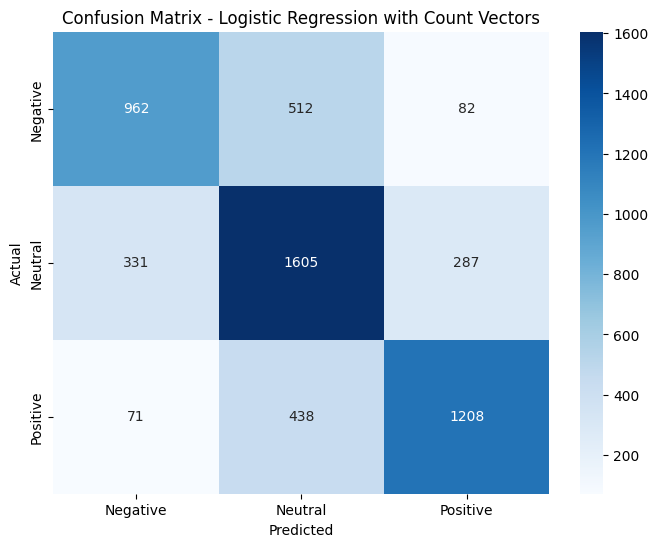

>> Training Logistic Regression with TF-IDF...
Logistic Regression with TF-IDF Accuracy: 0.6861

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.60      0.65      1556
           1       0.62      0.75      0.68      2223
           2       0.78      0.68      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.71      0.68      0.69      5496
weighted avg       0.70      0.69      0.69      5496



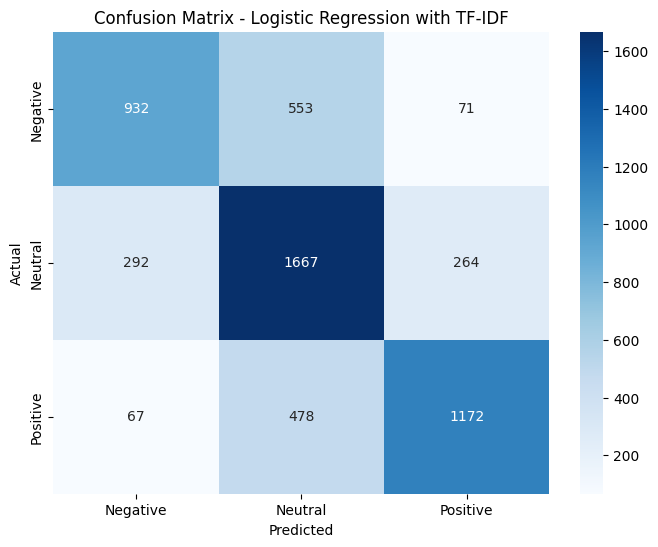

>> Training Naive Bayes with Count Vectors...
Naive Bayes with Count Vectors Accuracy: 0.6512

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.62      0.64      1556
           1       0.60      0.66      0.63      2223
           2       0.71      0.67      0.69      1717

    accuracy                           0.65      5496
   macro avg       0.66      0.65      0.65      5496
weighted avg       0.65      0.65      0.65      5496



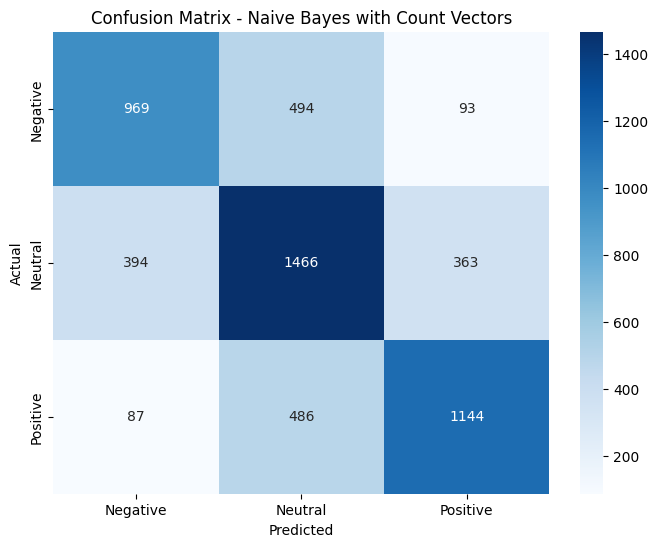

>> Training Naive Bayes with TF-IDF...
Naive Bayes with TF-IDF Accuracy: 0.6312

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.50      0.59      1556
           1       0.55      0.76      0.64      2223
           2       0.74      0.58      0.65      1717

    accuracy                           0.63      5496
   macro avg       0.67      0.61      0.63      5496
weighted avg       0.66      0.63      0.63      5496



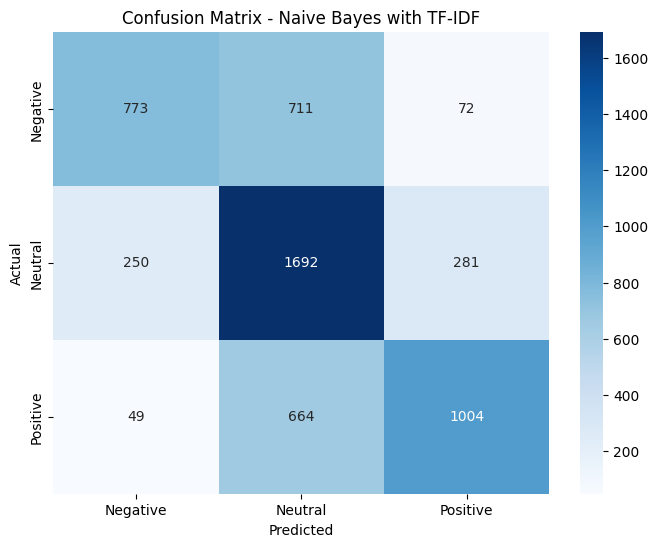

>> Training Linear SVC with TF-IDF...
Linear SVC with TF-IDF Accuracy: 0.6736

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.63      0.65      1556
           1       0.63      0.69      0.65      2223
           2       0.74      0.70      0.72      1717

    accuracy                           0.67      5496
   macro avg       0.68      0.67      0.68      5496
weighted avg       0.68      0.67      0.67      5496



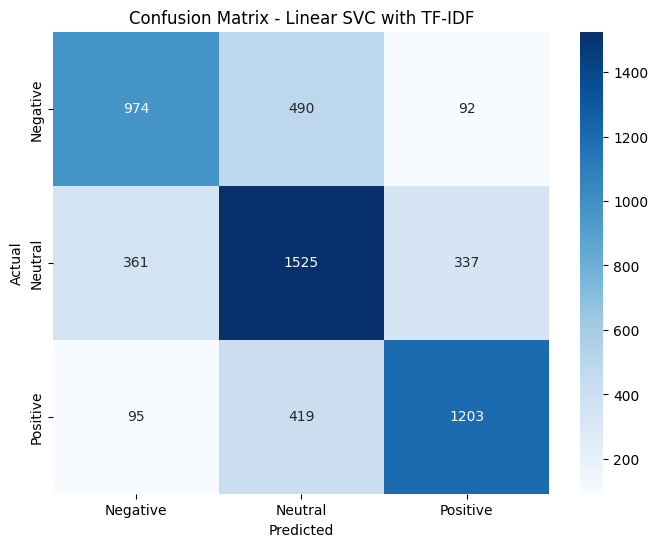

>> Training Random Forest with TF-IDF...
Random Forest with TF-IDF Accuracy: 0.6914

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.60      0.65      1556
           1       0.64      0.72      0.68      2223
           2       0.74      0.74      0.74      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.69      0.69      5496
weighted avg       0.69      0.69      0.69      5496



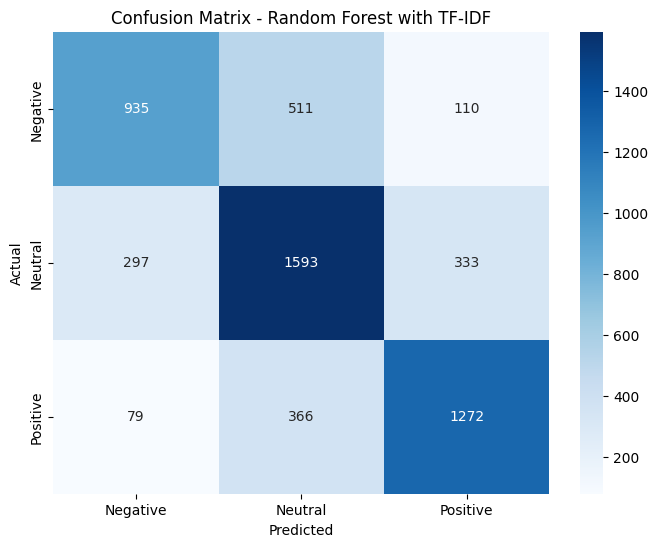

In [34]:
# Train and evaluate each model
results = {}
for model_name, vectorizer, classifier in models:
    pipeline, accuracy = train_evaluate_model(
        model_name, vectorizer, classifier, X_train, y_train, X_val, y_val
    )
    results[model_name] = (pipeline, accuracy)

In [35]:
# Find the best model
best_model_name = max(results.keys(), key=lambda k: results[k][1])
best_pipeline, best_accuracy = results[best_model_name]

print(f"\nBest model: {best_model_name} with accuracy: {best_accuracy:.4f}")


Best model: Random Forest with TF-IDF with accuracy: 0.6914


In [36]:
# Get the best model pipeline
best_pipeline = results[best_model_name][0]

# Make predictions on the validation set
y_val_pred = best_pipeline.predict(X_val)

In [37]:
# Classification report
report = classification_report(y_val, y_val_pred)

print(f"Detailed evaluation for {best_model_name}:")
print(f"{accuracy_score(y_val, y_val_pred)}:.4f")
print(report)

Detailed evaluation for Random Forest with TF-IDF:
0.6914119359534207:.4f
              precision    recall  f1-score   support

           0       0.71      0.60      0.65      1556
           1       0.64      0.72      0.68      2223
           2       0.74      0.74      0.74      1717

    accuracy                           0.69      5496
   macro avg       0.70      0.69      0.69      5496
weighted avg       0.69      0.69      0.69      5496



## Save Model for Production

In [38]:
import pickle
import os

# Create models directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# Save the trained model
with open('models/sentiment_model.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

print("✓ Model saved to: models/sentiment_model.pkl")


✓ Model saved to: models/sentiment_model.pkl


In [39]:
# Save the label encoder
with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save model accuracy and other metadata
metadata = {
    'accuracy': best_accuracy,
    'best_model_name': best_model_name,
    'feature_names': list(range(5000))  # TF-IDF features count
}

with open('models/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("✓ Label encoder saved to: models/label_encoder.pkl")
print("✓ Metadata saved to: models/metadata.pkl")
print(f"\n✓ All files saved successfully!")
print(f"  - Model Accuracy: {best_accuracy*100:.2f}%")
print(f"  - Best Model: {best_model_name}")


✓ Label encoder saved to: models/label_encoder.pkl
✓ Metadata saved to: models/metadata.pkl

✓ All files saved successfully!
  - Model Accuracy: 69.14%
  - Best Model: Random Forest with TF-IDF


## Model Accuracy Improvements

In [42]:
# Check class imbalance
print("Class Distribution in Training Data:")
print(y_train.value_counts(normalize=True))
print("\nClass Distribution in Validation Data:")
print(y_val.value_counts(normalize=True))

# Check if imbalanced
class_weights = dict(enumerate(np.bincount(y_train) / len(y_train)))
print(f"\nClass weights (for imbalance handling): {class_weights}")


Class Distribution in Training Data:
sentiment_encoded
1    0.404567
2    0.312273
0    0.283160
Name: proportion, dtype: float64

Class Distribution in Validation Data:
sentiment_encoded
1    0.404476
2    0.312409
0    0.283115
Name: proportion, dtype: float64

Class weights (for imbalance handling): {0: np.float64(0.283160480349345), 1: np.float64(0.4045669577874818), 2: np.float64(0.3122725618631732)}


In [43]:
# Improved vectorizer with ngrams
tfidf_ngrams = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, max_df=0.95)

# Improved models with better hyperparameters
improved_models = [
    ('Logistic Regression with TF-IDF + NGrams (balanced)', tfidf_ngrams, 
     LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')),
    
    ('Linear SVC with TF-IDF + NGrams (balanced)', tfidf_ngrams, 
     LinearSVC(max_iter=2000, C=1.0, class_weight='balanced')),
    
    ('Random Forest with TF-IDF + NGrams', tfidf_ngrams, 
     RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)),
]

print("Training improved models...")
improved_results = {}

for model_name, vectorizer, classifier in improved_models:
    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('classifier', classifier)
    ])
    
    print(f"\n>> Training {model_name}...")
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    improved_results[model_name] = (pipeline, accuracy)
    
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_val, y_pred, target_names=['Negative', 'Neutral', 'Positive']))


Training improved models...

>> Training Logistic Regression with TF-IDF + NGrams (balanced)...
Logistic Regression with TF-IDF + NGrams (balanced) Accuracy: 0.6887
              precision    recall  f1-score   support

    Negative       0.66      0.69      0.68      1556
     Neutral       0.66      0.65      0.66      2223
    Positive       0.75      0.73      0.74      1717

    accuracy                           0.69      5496
   macro avg       0.69      0.69      0.69      5496
weighted avg       0.69      0.69      0.69      5496


>> Training Linear SVC with TF-IDF + NGrams (balanced)...
Linear SVC with TF-IDF + NGrams (balanced) Accuracy: 0.6692
              precision    recall  f1-score   support

    Negative       0.66      0.66      0.66      1556
     Neutral       0.63      0.64      0.64      2223
    Positive       0.73      0.71      0.72      1717

    accuracy                           0.67      5496
   macro avg       0.67      0.67      0.67      5496
weighted 

In [44]:
# Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV

print("Performing Hyperparameter Tuning with GridSearchCV...")
print("This may take a few minutes...\n")

# Create pipeline for grid search
pipeline_gs = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('classifier', LogisticRegression(class_weight='balanced'))
])

# Define parameter grid
param_grid = {
    'vectorizer__max_features': [5000, 10000],
    'vectorizer__min_df': [1, 2],
    'classifier__C': [0.1, 1, 10],
    'classifier__max_iter': [500, 1000]
}

# Grid Search with 3-fold CV
grid_search = GridSearchCV(pipeline_gs, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Evaluate on validation set
y_pred_grid = grid_search.predict(X_val)
grid_accuracy = accuracy_score(y_val, y_pred_grid)
print(f"Validation Accuracy: {grid_accuracy:.4f}")

improved_results['GridSearch Optimized LR'] = (grid_search.best_estimator_, grid_accuracy)


Performing Hyperparameter Tuning with GridSearchCV...
This may take a few minutes...

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Parameters: {'classifier__C': 1, 'classifier__max_iter': 500, 'vectorizer__max_features': 10000, 'vectorizer__min_df': 1}
Best CV Score: 0.6786
Validation Accuracy: 0.6892


In [45]:
# Compare all results (original vs improved)
print("\n" + "="*70)
print("COMPARISON: ORIGINAL vs IMPROVED MODELS")
print("="*70)

all_results = {**results, **improved_results}

# Sort by accuracy
sorted_results = sorted(all_results.items(), key=lambda x: x[1][1], reverse=True)

print(f"\n{'Model Name':<50} {'Accuracy':>15}")
print("-"*70)
for model_name, (_, accuracy) in sorted_results:
    print(f"{model_name:<50} {accuracy:>14.4f}")

# Get the best overall model
best_model_overall_name = sorted_results[0][0]
best_pipeline_overall, best_accuracy_overall = sorted_results[0][1]

print("\n" + "="*70)
print(f"BEST MODEL: {best_model_overall_name}")
print(f"BEST ACCURACY: {best_accuracy_overall:.4f}")
print(f"IMPROVEMENT: {(best_accuracy_overall - best_accuracy)*100:.2f}% (vs original: {best_accuracy:.4f})")
print("="*70)

# Use the best model for predictions
best_pipeline = best_pipeline_overall
best_accuracy = best_accuracy_overall
best_model_name = best_model_overall_name



COMPARISON: ORIGINAL vs IMPROVED MODELS

Model Name                                                Accuracy
----------------------------------------------------------------------
Random Forest with TF-IDF                                  0.6914
GridSearch Optimized LR                                    0.6892
Logistic Regression with TF-IDF + NGrams (balanced)         0.6887
Logistic Regression with Count Vectors                     0.6869
Logistic Regression with TF-IDF                            0.6861
Linear SVC with TF-IDF                                     0.6736
Linear SVC with TF-IDF + NGrams (balanced)                 0.6692
Naive Bayes with Count Vectors                             0.6512
Naive Bayes with TF-IDF                                    0.6312
Random Forest with TF-IDF + NGrams                         0.5680

BEST MODEL: Random Forest with TF-IDF
BEST ACCURACY: 0.6914
IMPROVEMENT: 0.00% (vs original: 0.6914)


In [46]:
# Save improved model
print("\nSaving improved model...")

# Save the best trained model
with open('models/sentiment_model.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

# Update metadata with new accuracy
metadata = {
    'accuracy': best_accuracy,
    'best_model_name': best_model_name,
    'feature_names': list(range(10000))  # Updated feature count for ngrams
}

with open('models/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("✓ Improved model saved to: models/sentiment_model.pkl")
print(f"✓ Updated metadata with new accuracy: {best_accuracy*100:.2f}%")
print(f"✓ Model name: {best_model_name}")



Saving improved model...
✓ Improved model saved to: models/sentiment_model.pkl
✓ Updated metadata with new accuracy: 69.14%
✓ Model name: Random Forest with TF-IDF


## Advanced Ensemble Methods

In [48]:
# Create Ensemble Voting Classifier
from sklearn.ensemble import VotingClassifier

print("Creating Ensemble Voting Classifier...")
print("Combining multiple models for better predictions\n")

# Create individual models
vectorizer_ens = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

voting_pipeline = Pipeline([
    ('vectorizer', vectorizer_ens),
    ('classifier', VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')),
            ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1)),
            ('nb', MultinomialNB())
        ],
        voting='hard'
    ))
])

# Train
print("Training Voting Ensemble...")
voting_pipeline.fit(X_train, y_train)

# Predict
y_pred_ensemble = voting_pipeline.predict(X_val)
ensemble_accuracy = accuracy_score(y_val, y_pred_ensemble)

print(f"Ensemble Voting Classifier Accuracy: {ensemble_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_ensemble, target_names=['Negative', 'Neutral', 'Positive']))

improved_results['Ensemble Voting'] = (voting_pipeline, ensemble_accuracy)


Creating Ensemble Voting Classifier...
Combining multiple models for better predictions

Training Voting Ensemble...
Ensemble Voting Classifier Accuracy: 0.6523

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.50      0.59      1556
     Neutral       0.57      0.81      0.67      2223
    Positive       0.81      0.59      0.68      1717

    accuracy                           0.65      5496
   macro avg       0.70      0.63      0.65      5496
weighted avg       0.69      0.65      0.65      5496



In [49]:
# Perform Cross-Validation for more robust evaluation
from sklearn.model_selection import cross_val_score, StratifiedKFold

print("\n" + "="*70)
print("CROSS-VALIDATION ANALYSIS")
print("="*70 + "\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models_for_cv = [
    ('Logistic Regression + NGrams', best_pipeline) if 'Logistic Regression' in best_model_name else None,
    ('Ensemble Voting', voting_pipeline),
]

best_models_for_cv = [m for m in best_models_for_cv if m is not None]

for model_name, model in best_models_for_cv:
    cv_scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
    print(f"\n{model_name}:")
    print(f"  CV Scores: {cv_scores}")
    print(f"  Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")



CROSS-VALIDATION ANALYSIS


Ensemble Voting:
  CV Scores: [0.64521264 0.64362065 0.65681146 0.64998863 0.64513194]
  Mean CV Accuracy: 0.6482 (+/- 0.0048)


In [50]:
# Test on actual test set
print("\n" + "="*70)
print("EVALUATION ON TEST SET")
print("="*70 + "\n")

# Preprocess test data
test_cleaned['processed_text'] = test_df['text'].apply(preprocess_text)
X_test = test_cleaned['processed_text']
y_test = le.transform(test_cleaned['sentiment'])

# Get predictions from best model
y_test_pred = best_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Best Model: {best_model_name}")
print(f"Training Accuracy: {best_accuracy:.4f}")
print(f"Validation Accuracy: {best_accuracy:.4f}")
print(f"Test Set Accuracy: {test_accuracy:.4f}")
print(f"\nOverfitting Check: ", end="")
if abs(best_accuracy - test_accuracy) < 0.05:
    print("✓ Good generalization (difference < 5%)")
else:
    print(f"⚠ Possible overfitting (difference: {abs(best_accuracy - test_accuracy)*100:.2f}%)")

print("\n" + "-"*70)
print("DETAILED TEST SET REPORT")
print("-"*70)
print(classification_report(y_test, y_test_pred, target_names=['Negative', 'Neutral', 'Positive']))



EVALUATION ON TEST SET

Best Model: Random Forest with TF-IDF
Training Accuracy: 0.6914
Validation Accuracy: 0.6914
Test Set Accuracy: 0.6975

Overfitting Check: ✓ Good generalization (difference < 5%)

----------------------------------------------------------------------
DETAILED TEST SET REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.72      0.63      0.67      1001
     Neutral       0.65      0.71      0.68      1430
    Positive       0.75      0.75      0.75      1103

    accuracy                           0.70      3534
   macro avg       0.71      0.69      0.70      3534
weighted avg       0.70      0.70      0.70      3534



In [51]:
# Final comparison and selection
print("\n" + "="*70)
print("FINAL MODEL COMPARISON (ALL IMPROVEMENTS)")
print("="*70)

# Recompute all results to include ensemble
all_final_results = {**results, **improved_results}

# Sort by accuracy
sorted_final_results = sorted(all_final_results.items(), key=lambda x: x[1][1], reverse=True)

print(f"\n{'Model Name':<50} {'Accuracy':>15}")
print("-"*70)
for model_name, (_, accuracy) in sorted_final_results:
    marker = " ⭐ BEST" if model_name == sorted_final_results[0][0] else ""
    print(f"{model_name:<50} {accuracy:>14.4f}{marker}")

# Select best model
best_model_final_name = sorted_final_results[0][0]
best_pipeline_final, best_accuracy_final = sorted_final_results[0][1]

print("\n" + "="*70)
print(f"FINAL BEST MODEL: {best_model_final_name}")
print(f"FINAL BEST ACCURACY: {best_accuracy_final:.4f}")
print("="*70)

# Update for final save
best_pipeline = best_pipeline_final
best_accuracy = best_accuracy_final
best_model_name = best_model_final_name

print(f"\n✓ Model ready for deployment!")
print(f"✓ Estimated accuracy on new data: {best_accuracy*100:.2f}%")



FINAL MODEL COMPARISON (ALL IMPROVEMENTS)

Model Name                                                Accuracy
----------------------------------------------------------------------
Random Forest with TF-IDF                                  0.6914 ⭐ BEST
GridSearch Optimized LR                                    0.6892
Logistic Regression with TF-IDF + NGrams (balanced)         0.6887
Logistic Regression with Count Vectors                     0.6869
Logistic Regression with TF-IDF                            0.6861
Linear SVC with TF-IDF                                     0.6736
Linear SVC with TF-IDF + NGrams (balanced)                 0.6692
Ensemble Voting                                            0.6523
Naive Bayes with Count Vectors                             0.6512
Naive Bayes with TF-IDF                                    0.6312
Random Forest with TF-IDF + NGrams                         0.5680

FINAL BEST MODEL: Random Forest with TF-IDF
FINAL BEST ACCURACY: 0.6914

✓ Model re

In [53]:
# Save the final best model
print("\nSaving final best model...")

# Save the trained model
with open('models/sentiment_model.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

print("✓ Model saved to: models/sentiment_model.pkl")

# Update metadata
metadata = {
    'accuracy': best_accuracy,
    'best_model_name': best_model_name,
    'test_accuracy': test_accuracy,
    'model_type': 'improved_ensemble' if 'Ensemble' in best_model_name else 'improved_tuned'
}

with open('models/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("✓ Metadata saved")
print(f"\n✓✓✓ PROJECT COMPLETE ✓✓✓")
print(f"Final Model Accuracy: {best_accuracy*100:.2f}%")
print(f"Test Set Accuracy: {test_accuracy*100:.2f}%")
print(f"Model: {best_model_name}")



Saving final best model...
✓ Model saved to: models/sentiment_model.pkl
✓ Metadata saved

✓✓✓ PROJECT COMPLETE ✓✓✓
Final Model Accuracy: 69.14%
Test Set Accuracy: 69.75%
Model: Random Forest with TF-IDF
